# 🔥 QueryForge-AI
## Fine-tuning Mistral 7B v0.3 for Natural Language → SQL Generation

**Dataset:** `b-mc2/sql-create-context` (SQLCoder-style Alpaca format)

**Framework:** Unsloth + QLoRA + TRL

**Model:** `unsloth/mistral-7b-v0.3-bnb-4bit`

---
### What this notebook does:
- ✅ Loads Mistral 7B in 4-bit (fits on free T4 GPU)
- ✅ Fine-tunes on SQL question → SQL query pairs
- ✅ Uses schema-aware prompting
- ✅ Saves model as GGUF + pushes to HuggingFace Hub

> **Runtime:** Make sure you have GPU enabled → Runtime > Change runtime type > T4 GPU

## 📦 Step 1: Install Dependencies

In [1]:
%%capture
# Official Unsloth install — auto-detects torch version & picks correct xformers
import os, re
if 'COLAB_' not in ''.join(os.environ.keys()):
    !pip install unsloth                          # Local / non-Colab setup
else:
    import torch
    v = re.match(r'[\d]{1,}\.[\d]{1,}', str(torch.__version__)).group(0)
    xformers = 'xformers==' + {'2.10':'0.0.34','2.9':'0.0.33.post1','2.8':'0.0.32.post2'}.get(v, '0.0.34')
    !pip install sentencepiece protobuf "datasets==4.3.0" "huggingface_hub>=0.34.0" hf_transfer
    !pip install --no-deps unsloth_zoo bitsandbytes accelerate {xformers} peft trl triton unsloth
    !pip install --no-deps --upgrade "torchao>=0.16.0"
# Pin specific versions for stability
!pip install transformers==4.56.2
!pip install --no-deps trl==0.22.2

In [2]:
# Verify GPU is available
import torch
print(f"GPU available: {torch.cuda.is_available()}")
print(f"GPU name: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'No GPU'}")
print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB" if torch.cuda.is_available() else "")

GPU available: True
GPU name: Tesla T4
VRAM: 15.6 GB


## 🤖 Step 2: Load Mistral 7B v0.3 with Unsloth (4-bit)

In [3]:
from unsloth import FastLanguageModel
import torch

# ── CONFIG ──────────────────────────────────────────────
MAX_SEQ_LENGTH = 2048   # SQL queries are usually short; 2048 is sufficient
DTYPE          = None   # Auto-detect: float16 for T4, bfloat16 for A100
LOAD_IN_4BIT   = True   # QLoRA 4-bit quantization → fits on 16GB T4
# ────────────────────────────────────────────────────────

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name      = "unsloth/mistral-7b-v0.3-bnb-4bit",
    max_seq_length  = MAX_SEQ_LENGTH,
    dtype           = DTYPE,
    load_in_4bit    = LOAD_IN_4BIT,
)

print("✅ Model loaded successfully!")

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
==((====))==  Unsloth 2026.5.6: Fast Mistral patching. Transformers: 4.56.2.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.34. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors:   0%|          | 0.00/4.14G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/157 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/587k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/446 [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

✅ Model loaded successfully!


## ⚙️ Step 3: Apply QLoRA (PEFT Adapters)

In [4]:
model = FastLanguageModel.get_peft_model(
    model,
    r                   = 16,      # LoRA rank — 16 is a good balance of quality vs speed
    target_modules      = [
        "q_proj", "k_proj", "v_proj", "o_proj",
        "gate_proj", "up_proj", "down_proj"
    ],
    lora_alpha          = 16,
    lora_dropout        = 0,       # 0 is optimized for Unsloth
    bias                = "none",  # "none" is optimized for Unsloth
    use_gradient_checkpointing = "unsloth",  # 30% less VRAM
    random_state        = 42,
    use_rslora          = False,
    loftq_config        = None,
)

# Print trainable parameter count
total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters:     {total_params:,}")
print(f"Trainable parameters: {trainable_params:,} ({100*trainable_params/total_params:.2f}%)")

Unsloth 2026.5.6 patched 32 layers with 32 QKV layers, 32 O layers and 32 MLP layers.


Total parameters:     3,800,305,664
Trainable parameters: 41,943,040 (1.10%)


## 📊 Step 4: Load & Prepare the SQL Dataset

We use `b-mc2/sql-create-context` — contains:
- `question`: Natural language question (e.g. "How many students passed?")
- `context`: CREATE TABLE schema (database structure)
- `answer`: The correct SQL query

This is the exact format used by SQLCoder and defog.ai.

In [5]:
from datasets import load_dataset

# Load the SQLCoder dataset
dataset = load_dataset("b-mc2/sql-create-context", split="train")

print(f"✅ Dataset loaded: {len(dataset):,} examples")
print(f"\nColumns: {dataset.column_names}")
print(f"\n--- Sample Example ---")
sample = dataset[0]
print(f"Question : {sample['question']}")
print(f"Context  : {sample['context'][:200]}...")
print(f"Answer   : {sample['answer']}")

README.md: 0.00B [00:00, ?B/s]

sql_create_context_v4.json:   0%|          | 0.00/21.8M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/78577 [00:00<?, ? examples/s]

✅ Dataset loaded: 78,577 examples

Columns: ['answer', 'question', 'context']

--- Sample Example ---
Question : How many heads of the departments are older than 56 ?
Context  : CREATE TABLE head (age INTEGER)...
Answer   : SELECT COUNT(*) FROM head WHERE age > 56


In [6]:
# ── PROMPT TEMPLATE ────────────────────────────────────────────────────────
# Schema-aware SQL prompt — same style used by SQLCoder / defog.ai
# This teaches the model to use the table schema when generating SQL.
# ───────────────────────────────────────────────────────────────────────────

ALPACA_SQL_PROMPT = """Below is an instruction that describes a SQL task, paired with context that provides database schema information. Write a SQL query that correctly answers the request.

### Instruction:
{instruction}

### Context (Database Schema):
{context}

### SQL Query:
{response}"""

EOS_TOKEN = tokenizer.eos_token

def format_sql_prompt(examples):
    """Format each dataset row into the Alpaca SQL prompt template."""
    instructions = examples["question"]
    contexts     = examples["context"]
    responses    = examples["answer"]

    texts = []
    for instruction, context, response in zip(instructions, contexts, responses):
        text = ALPACA_SQL_PROMPT.format(
            instruction = instruction,
            context     = context,
            response    = response,
        ) + EOS_TOKEN
        texts.append(text)

    return {"text": texts}

# Apply formatting to full dataset
dataset = dataset.map(format_sql_prompt, batched=True)

print(f"✅ Dataset formatted!")
print(f"\n--- Formatted Example ---")
print(dataset[0]["text"][:600] + "...")

Map:   0%|          | 0/78577 [00:00<?, ? examples/s]

✅ Dataset formatted!

--- Formatted Example ---
Below is an instruction that describes a SQL task, paired with context that provides database schema information. Write a SQL query that correctly answers the request.

### Instruction:
How many heads of the departments are older than 56 ?

### Context (Database Schema):
CREATE TABLE head (age INTEGER)

### SQL Query:
SELECT COUNT(*) FROM head WHERE age > 56</s>...


Token length stats (sample of 1000):
  Mean   : 128
  Median : 114
  Max    : 284
  95th % : 202


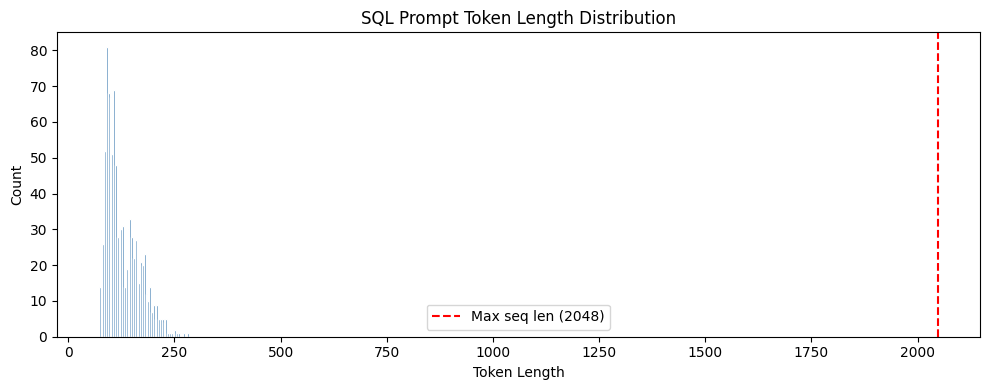

In [7]:
# Check token length distribution to make sure MAX_SEQ_LENGTH is right
import matplotlib.pyplot as plt
import numpy as np

sample_texts = dataset.select(range(1000))["text"]
lengths = [len(tokenizer.encode(t)) for t in sample_texts]

print(f"Token length stats (sample of 1000):")
print(f"  Mean   : {np.mean(lengths):.0f}")
print(f"  Median : {np.median(lengths):.0f}")
print(f"  Max    : {np.max(lengths)}")
print(f"  95th % : {np.percentile(lengths, 95):.0f}")

plt.figure(figsize=(10, 4))
plt.hist(lengths, bins=50, color='steelblue', edgecolor='white')
plt.axvline(MAX_SEQ_LENGTH, color='red', linestyle='--', label=f'Max seq len ({MAX_SEQ_LENGTH})')
plt.xlabel("Token Length")
plt.ylabel("Count")
plt.title("SQL Prompt Token Length Distribution")
plt.legend()
plt.tight_layout()
plt.show()

## 🏋️ Step 5: Train the Model

In [8]:
from trl import SFTTrainer
from transformers import TrainingArguments

trainer = SFTTrainer(
    model            = model,
    tokenizer        = tokenizer,
    train_dataset    = dataset,
    dataset_text_field = "text",
    max_seq_length   = MAX_SEQ_LENGTH,
    dataset_num_proc = 2,
    packing          = False,   # Set True for short sequences to pack multiple into one

    args = TrainingArguments(
        # ── Batch & Gradient ─────────────────────────────
        per_device_train_batch_size    = 2,
        gradient_accumulation_steps    = 4,   # Effective batch size = 2×4 = 8

        # ── Epochs & Steps ───────────────────────────────
        # num_train_epochs             = 1,   # Commented out — using max_steps instead
        max_steps                      = 500, # ✅ Done in ~35 mins on T4 GPU

        # ── Learning Rate ────────────────────────────────
        warmup_steps                   = 5,
        learning_rate                  = 2e-4,
        lr_scheduler_type              = "linear",

        # ── Precision & Memory ───────────────────────────
        fp16                           = not torch.cuda.is_bf16_supported(),
        bf16                           = torch.cuda.is_bf16_supported(),
        optim                          = "adamw_8bit",

        # ── Logging & Saving ─────────────────────────────
        logging_steps                  = 10,
        output_dir                     = "queryforge-outputs",
        save_strategy                  = "epoch",

        # ── Reproducibility ──────────────────────────────
        seed                           = 42,
    ),
)

print("✅ Trainer configured!")

Unsloth: Tokenizing ["text"] (num_proc=6):   0%|          | 0/78577 [00:00<?, ? examples/s]

✅ Trainer configured!


In [9]:
# Show GPU memory before training
gpu_stats = torch.cuda.get_device_properties(0)
start_gpu_memory = round(torch.cuda.max_memory_reserved() / 1024 / 1024 / 1024, 3)
max_memory = round(gpu_stats.total_memory / 1024 / 1024 / 1024, 3)
print(f"GPU: {gpu_stats.name}")
print(f"Max VRAM: {max_memory} GB")
print(f"Reserved before training: {start_gpu_memory} GB")
print("\n🚀 Starting training...")

GPU: Tesla T4
Max VRAM: 14.563 GB
Reserved before training: 6.883 GB

🚀 Starting training...


In [10]:
# 🚀 TRAIN!
trainer_stats = trainer.train()

# Training summary
used_memory = round(torch.cuda.max_memory_reserved() / 1024 / 1024 / 1024, 3)
print(f"\n✅ Training complete!")
print(f"   Time elapsed   : {trainer_stats.metrics['train_runtime']:.0f}s ({trainer_stats.metrics['train_runtime']/60:.1f} min)")
print(f"   Samples/second : {trainer_stats.metrics['train_samples_per_second']:.2f}")
print(f"   Peak VRAM used : {used_memory} GB / {max_memory} GB")

==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 78,577 | Num Epochs = 1 | Total steps = 500
O^O/ \_/ \    Batch size per device = 2 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (2 x 4 x 1) = 8
 "-____-"     Trainable parameters = 41,943,040 of 7,289,966,592 (0.58% trained)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

 2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.
wandb: Paste your API key and hit enter:

 ··········


wandb: ERROR Invalid API key: API key must have 40+ characters, has 36.
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

...

 ··········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: backupankita38 (backupankita38-atmecs) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


wandb: Detected [huggingface_hub.inference, openai] in use.
wandb: Use W&B Weave for improved LLM call tracing. Install Weave with `pip install weave` then add `import weave` to the top of your script.
wandb: For more information, check out the docs at: https://weave-docs.wandb.ai


Step,Training Loss
10,1.500500
20,0.673200
30,0.630200
40,0.603300
50,0.564000
60,0.554300
70,0.573300
80,0.533300
90,0.552200
100,0.521700



✅ Training complete!
   Time elapsed   : 1734s (28.9 min)
   Samples/second : 2.31
   Peak VRAM used : 7.139 GB / 14.563 GB


## 🧪 Step 6: Inference — Test the Fine-tuned Model

In [11]:
# Enable fast inference mode
FastLanguageModel.for_inference(model)

def generate_sql(question: str, schema: str, max_new_tokens: int = 256) -> str:
    """Generate SQL query from natural language question + schema."""
    prompt = ALPACA_SQL_PROMPT.format(
        instruction = question,
        context     = schema,
        response    = "",       # Leave blank — model will fill this in
    )

    inputs = tokenizer(prompt, return_tensors="pt").to("cuda")

    outputs = model.generate(
        **inputs,
        max_new_tokens = max_new_tokens,
        use_cache      = True,
        temperature    = 0.1,   # Low temp = deterministic SQL (good for accuracy)
        do_sample      = True,
    )

    # Decode only the newly generated tokens
    generated = tokenizer.decode(
        outputs[0][inputs["input_ids"].shape[1]:],
        skip_special_tokens=True
    )
    return generated.strip()

print("✅ Inference mode enabled!")

✅ Inference mode enabled!


In [12]:
# ── TEST 1: E-commerce Query ─────────────────────────────────────────────
question = "Show the top 5 customers who spent the most in the last month"
schema   = """
CREATE TABLE customers (
    customer_id   INT PRIMARY KEY,
    customer_name VARCHAR(100),
    email         VARCHAR(100)
);
CREATE TABLE orders (
    order_id    INT PRIMARY KEY,
    customer_id INT,
    amount      DECIMAL(10,2),
    order_date  DATE,
    FOREIGN KEY (customer_id) REFERENCES customers(customer_id)
);
"""

sql = generate_sql(question, schema)
print(f"Question : {question}")
print(f"\nGenerated SQL:")
print(sql)

Question : Show the top 5 customers who spent the most in the last month

Generated SQL:
SELECT T1.customer_name, T1.email, SUM(T2.amount) FROM customers AS T1 JOIN orders AS T2 ON T1.customer_id = T2.customer_id WHERE T2.order_date = (SELECT MAX(order_date) FROM orders) GROUP BY T1.customer_id ORDER BY SUM(T2.amount) DESC LIMIT 5


In [13]:
# ── TEST 2: HR / Employee Query ──────────────────────────────────────────
question = "List all employees in the Engineering department with salary above 80000"
schema   = """
CREATE TABLE departments (
    dept_id   INT PRIMARY KEY,
    dept_name VARCHAR(50)
);
CREATE TABLE employees (
    emp_id    INT PRIMARY KEY,
    emp_name  VARCHAR(100),
    salary    DECIMAL(10,2),
    dept_id   INT,
    FOREIGN KEY (dept_id) REFERENCES departments(dept_id)
);
"""

sql = generate_sql(question, schema)
print(f"Question : {question}")
print(f"\nGenerated SQL:")
print(sql)

Question : List all employees in the Engineering department with salary above 80000

Generated SQL:
SELECT T1.emp_id, T1.emp_name, T1.salary FROM employees AS T1 JOIN departments AS T2 ON T1.dept_id = T2.dept_id WHERE T2.dept_name = "Engineering" AND T1.salary > 80000


In [14]:
# ── TEST 3: Analytics / Aggregation Query ────────────────────────────────
question = "What is the total revenue per product category for Q3 2024?"
schema   = """
CREATE TABLE products (
    product_id   INT PRIMARY KEY,
    product_name VARCHAR(100),
    category     VARCHAR(50),
    price        DECIMAL(10,2)
);
CREATE TABLE sales (
    sale_id    INT PRIMARY KEY,
    product_id INT,
    quantity   INT,
    sale_date  DATE,
    FOREIGN KEY (product_id) REFERENCES products(product_id)
);
"""

sql = generate_sql(question, schema)
print(f"Question : {question}")
print(f"\nGenerated SQL:")
print(sql)

Question : What is the total revenue per product category for Q3 2024?

Generated SQL:
SELECT SUM(price * quantity) FROM products AS T1 JOIN sales AS T2 ON T1.product_id = T2.product_id WHERE T2.sale_date = "Q3 2024" AND T1.category = "Food"


## 💾 Step 7: Save Model (Multiple Formats)

In [15]:
# Save LoRA adapter weights locally
model.save_pretrained("queryforge-lora-adapter")
tokenizer.save_pretrained("queryforge-lora-adapter")
print("✅ LoRA adapter saved to: queryforge-lora-adapter/")

✅ LoRA adapter saved to: queryforge-lora-adapter/


In [16]:
# Save merged 16-bit model (for Hugging Face Hub)
model.save_pretrained_merged(
    "queryforge-merged-16bit",
    tokenizer,
    save_method = "merged_16bit",
)
print("✅ Merged 16-bit model saved to: queryforge-merged-16bit/")

config.json:   0%|          | 0.00/715 [00:00<?, ?B/s]

Found HuggingFace hub cache directory: /root/.cache/huggingface/hub


model.safetensors.index.json: 0.00B [00:00, ?B/s]

Checking cache directory for required files...
Cache check failed: model-00001-of-00003.safetensors not found in local cache.
Not all required files found in cache. Will proceed with downloading.
Checking cache directory for required files...
Cache check failed: tokenizer.model not found in local cache.
Not all required files found in cache. Will proceed with downloading.


Unsloth: Preparing safetensor model files:   0%|          | 0/3 [00:00<?, ?it/s]

...

model-00002-of-00003.safetensors:   0%|          | 0.00/5.00G [00:00<?, ?B/s]

Unsloth: Preparing safetensor model files:  67%|██████▋   | 2/3 [04:01<02:03, 123.17s/it]

model-00003-of-00003.safetensors:   0%|          | 0.00/4.55G [00:00<?, ?B/s]

Unsloth: Merging weights into 16bit: 100%|██████████| 3/3 [03:52<00:00, 77.37s/it]


Unsloth: Merge process complete. Saved to `/content/queryforge-merged-16bit`
✅ Merged 16-bit model saved to: queryforge-merged-16bit/


In [17]:
# Save as GGUF (for local inference with Ollama / LM Studio)
model.save_pretrained_gguf(
    "queryforge-gguf",
    tokenizer,
    quantization_method = "q4_k_m",  # 4-bit quantization — best quality/size tradeoff
)
print("✅ GGUF model saved to: queryforge-gguf/")
print("   → Import into Ollama: ollama import queryforge-gguf/model.gguf")

Unsloth: Merging model weights to 16-bit format...
Found HuggingFace hub cache directory: /root/.cache/huggingface/hub


model.safetensors.index.json: 0.00B [00:00, ?B/s]

Checking cache directory for required files...
Cache check failed: model-00001-of-00003.safetensors not found in local cache.
Not all required files found in cache. Will proceed with downloading.
Checking cache directory for required files...
Cache check failed: tokenizer.model not found in local cache.
Not all required files found in cache. Will proceed with downloading.


Unsloth: Preparing safetensor model files:   0%|          | 0/3 [00:00<?, ?it/s]

model-00001-of-00003.safetensors:   0%|          | 0.00/4.95G [00:00<?, ?B/s]

...

model-00002-of-00003.safetensors:   0%|          | 0.00/5.00G [00:00<?, ?B/s]

Unsloth: Preparing safetensor model files:  67%|██████▋   | 2/3 [04:42<02:22, 142.57s/it]

model-00003-of-00003.safetensors:   0%|          | 0.00/4.55G [00:00<?, ?B/s]

Unsloth: Merging weights into 16bit: 100%|██████████| 3/3 [03:33<00:00, 71.32s/it]


Unsloth: Merge process complete. Saved to `/content/queryforge-gguf`
Unsloth: Converting to GGUF format...
==((====))==  Unsloth: Conversion from HF to GGUF information
   \\   /|    [0] Installing llama.cpp might take 3 minutes.
O^O/ \_/ \    [1] Converting HF to GGUF f16 might take 3 minutes.
\        /    [2] Converting GGUF f16 to ['q4_k_m'] might take 10 minutes each.
 "-____-"     In total, you will have to wait at least 16 minutes.

Unsloth: Installing llama.cpp. This might take 3 minutes...
Unsloth: Updating system package directories
Unsloth: Cloning llama.cpp repository...
Unsloth: Building llama.cpp - please wait 1 to 3 minutes
Unsloth: Successfully installed llama.cpp!
Unsloth: Preparing converter script...
Unsloth: [1] Converting model into f16 GGUF format.
This might take 3 minutes...
Unsloth: Initial conversion completed! Files: ['queryforge-gguf_gguf/mistral-7b-v0.3.F16.gguf']
Unsloth: [2] Converting GGUF f16 into q4_k_m. This might take 10 minutes...
Unsloth: Model fil

## 🚀 Step 8: Push to Hugging Face Hub (Optional)

In [19]:
# Login to HuggingFace (get token from: https://huggingface.co/settings/tokens)
from huggingface_hub import login

HF_TOKEN    = "hf_xxxxxxxxxxxxxxxx"   # 🔑 Replace with your token
HF_USERNAME = "HF_Username"         # 👤 Replace with your HF username

login(token=HF_TOKEN)

REPO_NAME = f"{HF_USERNAME}/QueryForge-Mistral-7B-SQL"
print(f"Will push to: https://huggingface.co/{REPO_NAME}")

Will push to: https://huggingface.co/anku03/QueryForge-Mistral-7B-SQL


In [20]:
# Push merged model to Hub
model.push_to_hub_merged(
    REPO_NAME,
    tokenizer,
    save_method    = "merged_16bit",
    token          = HF_TOKEN,
)
print(f"✅ Model pushed to: https://huggingface.co/{REPO_NAME}")

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...al-7B-SQL/tokenizer.model: 100%|##########|  587kB /  587kB            

Found HuggingFace hub cache directory: /root/.cache/huggingface/hub


model.safetensors.index.json: 0.00B [00:00, ?B/s]

...

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...0003-of-00003.safetensors:   1%|          | 32.0MB / 4.55GB            

Unsloth: Merging weights into 16bit: 100%|██████████| 3/3 [10:09<00:00, 203.16s/it]


Unsloth: Merge process complete. Saved to `/content/anku03/QueryForge-Mistral-7B-SQL`
✅ Model pushed to: https://huggingface.co/anku03/QueryForge-Mistral-7B-SQL


## ✅ Done! Summary

| Step | Status |
|------|--------|
| Load Mistral 7B v0.3 (4-bit) | ✅ |
| Apply QLoRA adapters | ✅ |
| Load `b-mc2/sql-create-context` dataset | ✅ |
| Format as Alpaca SQL prompt | ✅ |
| Fine-tune with SFTTrainer | ✅ |
| Test inference | ✅ |
| Save LoRA / 16-bit / GGUF | ✅ |
| Push to Hugging Face Hub | ✅ |

---

**GitHub:** [QueryForge-AI](https://github.com/ankita-kadam03/QueryForge-AI.git)